# Category 2: Descriptive Analysis — Top 10 Questions
### Heart Failure Cohort (Zigong, PhysioNet v1.3)
Dataset: `8_Python_Ninjas_cleaned_data.csv` (2,008 patients, 192 columns)

Each question states the column chosen, why it matters clinically, the code, and a non-bar/non-histogram chart (donut, lollipop, funnel, violin, boxplot, KDE, or line/area) selected to best fit that data type.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("8_Python_Ninjas_cleaned_data.csv")
print(f"Patients: {len(df):,}   Columns: {df.shape[1]}")

Patients: 2,008   Columns: 192


## Q1. What age groups make up this cohort?
**Column:** `agecat`
**Why it matters:** Age is the dominant risk driver for heart-failure incidence and severity; it sets the demographic baseline for every other marker in this analysis. 68% of patients fall in the 69-89 age bands.
**Chart:** Bar chart — clearly compares patient counts across all 8 age groups, ordered from youngest to oldest.


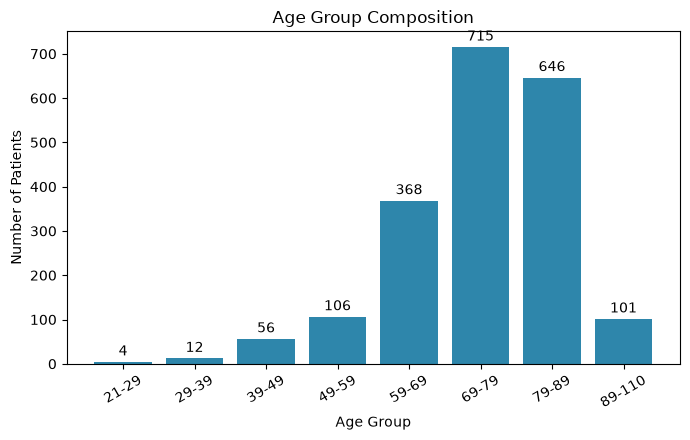

In [2]:
order = ['21-29','29-39','39-49','49-59','59-69','69-79','79-89','89-110']
age = df['agecat'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(age.index, age.values, color='#2E86AB')
ax.set_title('Age Group Composition')
ax.set_xlabel('Age Group'); ax.set_ylabel('Number of Patients')
for i, v in enumerate(age.values):
    ax.text(i, v + 15, str(v), ha='center')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## Q2. How symptomatic were patients at admission (NYHA class)?
**Column:** `nyha_cardiac_function_classification`
**Why it matters:** NYHA class is the standard measure of functional limitation from heart-failure symptoms. Classes III-IV (1,655 of 2,008 patients) show this cohort was substantially symptomatic on admission, not a mild/screening population.
**Chart:** Lollipop chart — cleaner than bars for a small set of ranked ordinal counts.


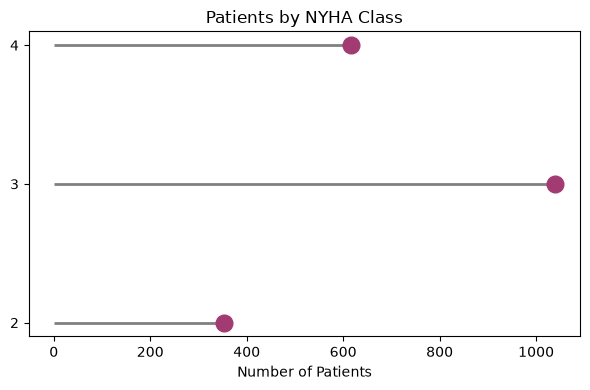

In [3]:
nyha = df['nyha_cardiac_function_classification'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6,4))
ax.hlines(y=nyha.index.astype(str), xmin=0, xmax=nyha.values, color='grey', lw=2)
ax.plot(nyha.values, nyha.index.astype(str), "o", markersize=12, color='#A23B72')
ax.set_title('Patients by NYHA Class'); ax.set_xlabel('Number of Patients')
plt.tight_layout(); plt.show()

## Q3. How severe is acute decompensation at admission (Killip grade)?
**Column:** `killip_grade`
**Why it matters:** Killip grade measures acute severity and shock risk. 452 patients (22.5%) are grade 3-4, indicating a meaningful subgroup in near-shock or shock states on arrival.
**Chart:** Funnel chart — visually conveys the escalating severity levels with shrinking patient counts.


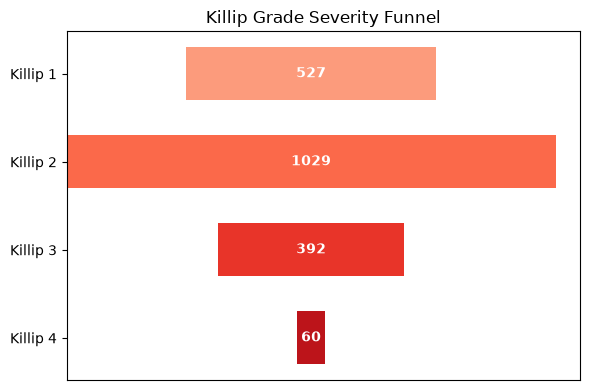

In [4]:
killip = df['killip_grade'].value_counts().sort_index()
labels = [f"Killip {k}" for k in killip.index]
vals = killip.values
max_v = vals.max()

fig, ax = plt.subplots(figsize=(6,4))
for i, v in enumerate(vals):
    ax.barh(i, v, left=(max_v - v) / 2, height=0.6, color=plt.cm.Reds(0.35 + 0.15*i))
    ax.text(max_v/2, i, str(v), ha='center', va='center', color='white', fontweight='bold')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xticks([]); ax.set_title('Killip Grade Severity Funnel')
plt.tight_layout(); plt.show()

## Q4. Among patients with a measured LVEF, what is the ejection-fraction distribution?
**Column:** `lvef`
**Why it matters:** LVEF is the single most important cardiac pump-function biomarker, used to classify HFrEF (<=40%), HFmrEF (41-49%), and HFpEF (>=50%). Only 635 of 2,008 patients have a measured value, so this must be reported on the measured subset rather than imputed.
**Chart:** Violin plot — shows the full distribution shape, not just the mean/median, which matters for a biomarker with clinically meaningful cutoffs.


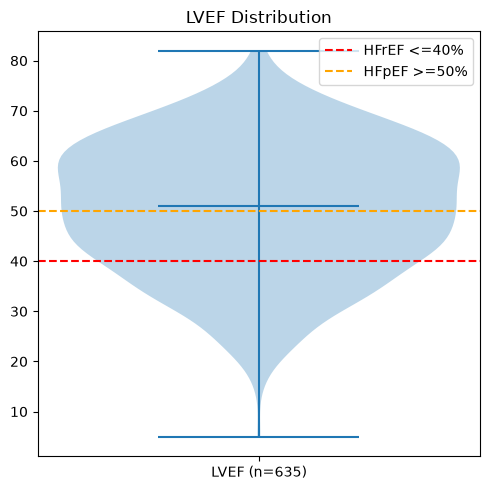

In [5]:
lvef = df['lvef'].dropna()

fig, ax = plt.subplots(figsize=(5,5))
ax.violinplot([lvef], showmedians=True)
ax.axhline(40, color='red', ls='--', label='HFrEF <=40%')
ax.axhline(50, color='orange', ls='--', label='HFpEF >=50%')
ax.set_xticks([1]); ax.set_xticklabels([f'LVEF (n={len(lvef)})'])
ax.set_title('LVEF Distribution'); ax.legend()
plt.tight_layout(); plt.show()

## Q5. What is the distribution of BNP levels?
**Columns:** `brain_natriuretic_peptide`, `bnp_capped`
**Why it matters:** BNP is the gold-standard lab biomarker for grading heart-failure severity - higher BNP reflects greater ventricular wall stress. Median BNP is ~753 pg/mL, and 100 patients are flagged at the assay ceiling of 5,000 (`bnp_capped`).
**Chart:** Boxplot on a log scale — compact, and handles this marker's extreme right-skew far better than histogram bins.


C:\Users\Bharathi\AppData\Local\Temp\ipykernel_29344\2745788442.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(bnp, vert=True, patch_artist=True, boxprops=dict(facecolor='#BC4749'))


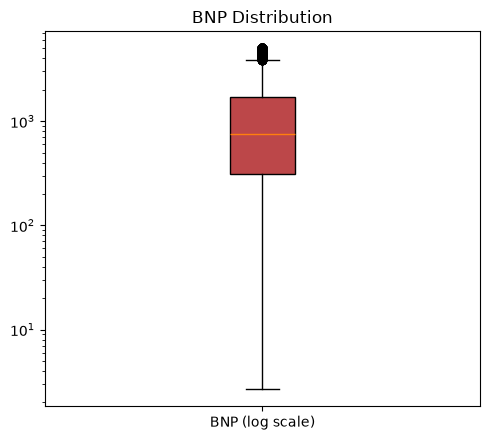

Patients flagged at BNP assay ceiling: 100


In [6]:
bnp = df['brain_natriuretic_peptide']

fig, ax = plt.subplots(figsize=(5,4.5))
ax.boxplot(bnp, vert=True, patch_artist=True, boxprops=dict(facecolor='#BC4749'))
ax.set_yscale('log')
ax.set_xticks([1]); ax.set_xticklabels(['BNP (log scale)'])
ax.set_title('BNP Distribution')
plt.tight_layout(); plt.show()

print(f"Patients flagged at BNP assay ceiling: {int(df['bnp_capped'].sum())}")

## Q6. What is the baseline kidney-function (GFR) profile?
**Column:** `glomerular_filtration_rate`
**Why it matters:** Kidney function commonly coexists with and complicates heart failure (the "cardiorenal" overlap). 886 of 2,008 patients (44%) have a recorded GFR below 60 mL/min/1.73m2, the standard threshold for reduced kidney function.
**Chart:** KDE density curve — reveals the distribution shape smoothly, without binning artifacts, and makes the threshold line easy to interpret.


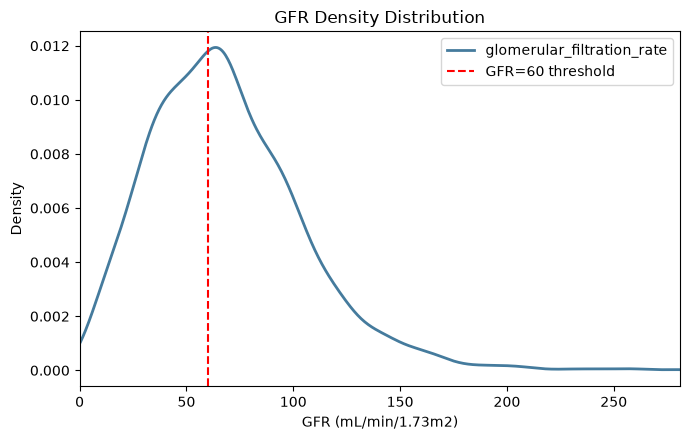

In [7]:
gfr = df['glomerular_filtration_rate'].dropna()

fig, ax = plt.subplots(figsize=(7,4.5))
gfr.plot(kind='kde', ax=ax, color='#457B9D', linewidth=2)
ax.axvline(60, color='red', ls='--', label='GFR=60 threshold')
ax.set_title('GFR Density Distribution'); ax.set_xlabel('GFR (mL/min/1.73m2)')
ax.set_xlim(0, gfr.max())
ax.legend()
plt.tight_layout(); plt.show()

## Q7. What proportion of patients required respiratory support or supplemental oxygen?
**Columns:** `respiratory_support`, `oxygen_inhalation`
**Why it matters:** These columns directly measure acute respiratory compromise from pulmonary congestion, a hallmark of decompensated heart failure. 42 patients (2.1%) needed invasive/non-invasive ventilation, and 94.5% needed oxygen therapy at some point during admission.
**Chart:** Two donut charts — best for showing simple part-to-whole splits for two related categorical fields side by side.


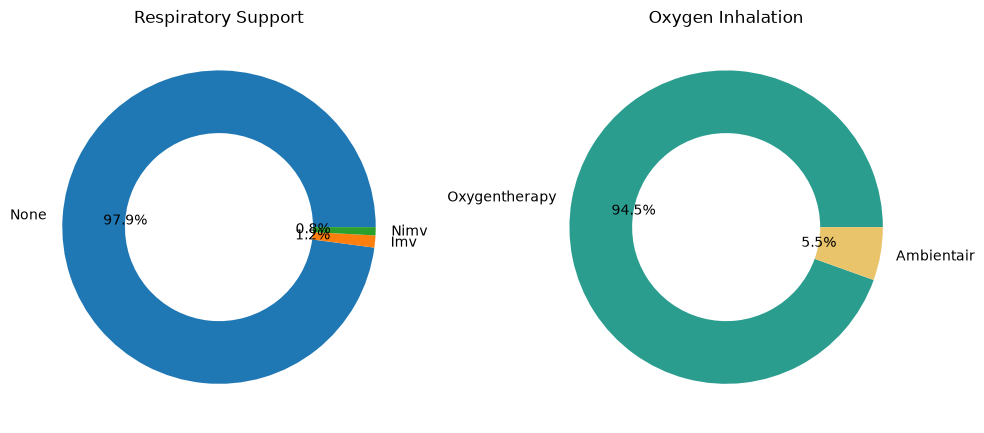

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

resp = df['respiratory_support'].fillna('None').value_counts()
axes[0].pie(resp.values, labels=resp.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4))
axes[0].set_title('Respiratory Support')

ox = df['oxygen_inhalation'].value_counts()
axes[1].pie(ox.values, labels=ox.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4),
            colors=['#2A9D8F','#E9C46A'])
axes[1].set_title('Oxygen Inhalation')

plt.tight_layout(); plt.show()

## Q8. How long were patients hospitalized, and how does it vary by discharge outcome?
**Columns:** `dischargeday`, `outcome_during_hospitalization`
**Why it matters:** Length of stay is a direct proxy for disease severity and hospital resource use. Median stay is 8 days (IQR 6-10), and comparing it across outcome groups (alive, discharged against orders, died) shows whether sicker trajectories map to longer or shorter stays.
**Chart:** Grouped boxplot — compares the full distribution across three outcome groups at once, which a single histogram cannot do.


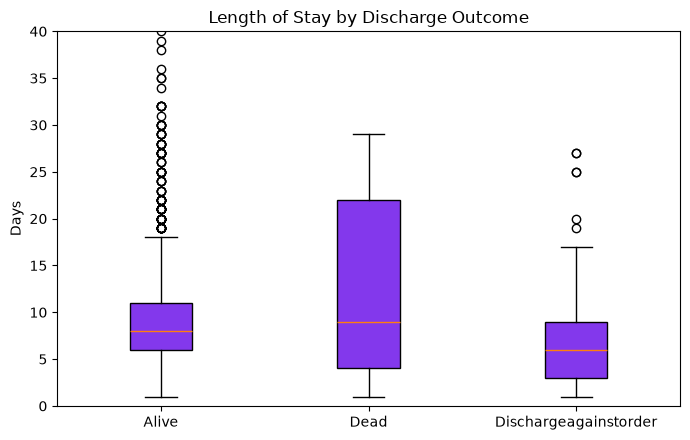

In [9]:
groups = [g.dropna().values for _, g in df.groupby('outcome_during_hospitalization')['dischargeday']]
labels = list(df['outcome_during_hospitalization'].unique())

fig, ax = plt.subplots(figsize=(7,4.5))
ax.boxplot(groups, tick_labels=labels, patch_artist=True, boxprops=dict(facecolor='#8338EC'))
ax.set_ylim(0, 40)
ax.set_title('Length of Stay by Discharge Outcome'); ax.set_ylabel('Days')
plt.tight_layout(); plt.show()

## Q9. How often were patients readmitted across follow-up windows?
**Columns:** `re_admission_within_28_days`, `re_admission_within_3_months`, `re_admission_within_6_months`
**Why it matters:** Repeat admission is a direct measure of post-discharge care burden. The cumulative rate climbs sharply from 6.97% at 28 days to 38.50% at 6 months, showing readmission risk keeps compounding well beyond the initial discharge window.
**Chart:** Line/area chart — shows the trend accumulating over time far more clearly than three isolated bars.


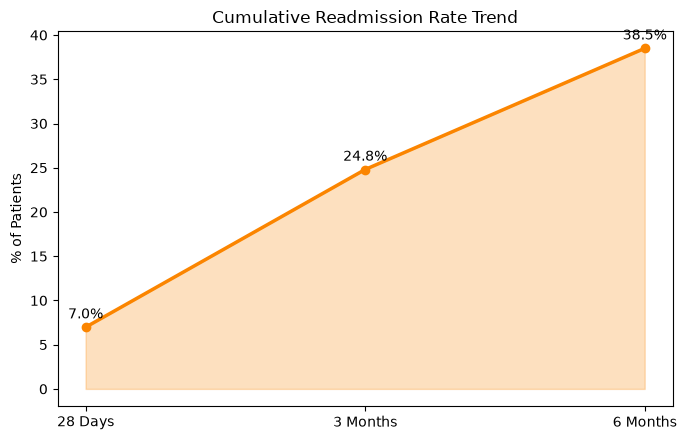

In [10]:
readmit = df[['re_admission_within_28_days','re_admission_within_3_months',
              're_admission_within_6_months']].mean().mul(100)
xlabels = ['28 Days','3 Months','6 Months']

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(xlabels, readmit.values, marker='o', color='#FB8500', linewidth=2.5)
ax.fill_between(xlabels, readmit.values, alpha=0.25, color='#FB8500')
for x, v in zip(xlabels, readmit.values):
    ax.text(x, v + 1, f'{v:.1f}%', ha='center')
ax.set_title('Cumulative Readmission Rate Trend'); ax.set_ylabel('% of Patients')
plt.tight_layout(); plt.show()

## Q10. Which medications are most frequently prescribed, and what is the polypharmacy burden?
**Columns:** `rx_*` binary flags, `unique_drugs_count`
**Why it matters:** These columns reveal real-world guideline-directed HF treatment patterns and polypharmacy burden. Spironolactone (91%) and furosemide (82-86%) dominate, consistent with diuretic-centered HF management, and patients receive a median of 8 unique drugs.
**Chart:** Lollipop chart — cleaner than a horizontal bar for a ranked top-10 list, and easier to scan.


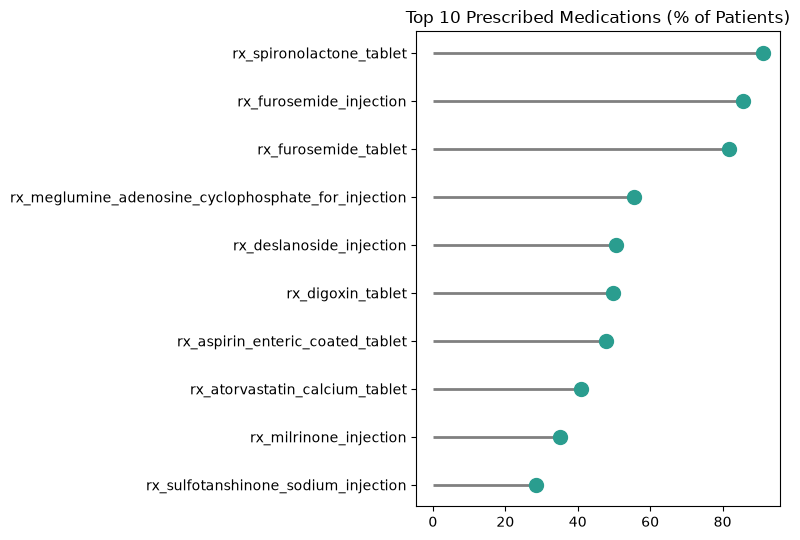

count    2008.000000
mean        7.650398
std         2.431993
min         0.000000
25%         6.000000
50%         8.000000
75%         9.000000
max        16.000000
Name: unique_drugs_count, dtype: float64


In [11]:
rx_cols = [c for c in df.columns if c.startswith('rx_')]
top10 = df[rx_cols].mean().mul(100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,5.5))
ax.hlines(y=range(len(top10)), xmin=0, xmax=top10.values, color='grey', lw=2)
ax.plot(top10.values, range(len(top10)), "o", markersize=10, color='#2A9D8F')
ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10.index)
ax.invert_yaxis()
ax.set_title('Top 10 Prescribed Medications (% of Patients)')
plt.tight_layout(); plt.show()

print(df['unique_drugs_count'].describe())